# Baseline 4 (Train from Scratch + Attention)

In [1]:
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


**Bước 1: Khai báo Thư viện và Thiết lập Hệ thống**

Giải thích:
- Nạp các công cụ cần thiết của PyTorch. Cố định seed để kết quả huấn luyện đồng nhất ở các lần chạy.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import random
from collections import Counter
from PIL import Image

# Cố định Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")

Đang sử dụng thiết bị: cuda


**Bước 2: Tải Dữ liệu Ảnh**

Giải thích:
- Tải ảnh của tập MS COCO Val 2014 trực tiếp về máy chủ để nạp dữ liệu nhanh hơn.

In [3]:
os.makedirs('/content/VQA_E/Images', exist_ok=True)
os.makedirs('/content/VQA_E/Annotations', exist_ok=True)

print("1. Đang tải Ảnh COCO Val 2014 (~6GB)...")
!wget -c -q http://images.cocodataset.org/zips/val2014.zip -P /content/VQA_E/Images/

print("2. Đang giải nén dữ liệu...")
!unzip -q -n /content/VQA_E/Images/val2014.zip -d /content/VQA_E/Images/

print("Hoàn tất tải và giải nén!")
# Đừng quên upload VQA-E_val_set.json vào /content/VQA_E/Annotations/

1. Đang tải Ảnh COCO Val 2014 (~6GB)...
2. Đang giải nén dữ liệu...
Hoàn tất tải và giải nén!


**Bước 3: Khai phá và Đồng bộ Dữ liệu**

Giải thích:

- Đọc JSON, mapping ID ảnh với file gốc và chia tập Train/Val.

In [5]:
def load_vqa_e_data(json_path, img_dir, max_samples=15000):
    print("Đang đọc file JSON VQA-E...")
    with open(json_path, 'r') as f:
        data = json.load(f)

    dataset = []
    for item in data:
        img_id = item['img_id']
        img_filename = f"COCO_val2014_{img_id:012d}.jpg"

        dataset.append({
            'image_path': os.path.join(img_dir, "val2014", img_filename),
            'question': item['question'],
            'explanation': item['explanation'][0]
        })

    random.shuffle(dataset)
    if max_samples:
        dataset = dataset[:max_samples]
    return dataset

JSON_PATH = '/content/VQA_E/Annotations/VQA-E_val_set.json'
IMG_DIR = '/content/VQA_E/Images'

all_data = load_vqa_e_data(JSON_PATH, IMG_DIR, max_samples=10000)

split_idx = int(len(all_data) * 0.8)
train_data = all_data[:split_idx]
val_data = all_data[split_idx:]
print(f"Số lượng Train: {len(train_data)} | Val: {len(val_data)}")

Đang đọc file JSON VQA-E...
Số lượng Train: 8000 | Val: 2000


**Bước 4: Xây dựng Từ điển (Vocabulary)**

Giải thích:

- Tạo từ điển ánh xạ từ vựng sang số nguyên (IDs), hoàn toàn học từ tập dữ liệu chứ không dùng pre-train (GloVe/Word2vec).

In [6]:
import re

class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos = {0: "<pad>", 1: "<sos>", 2: "<eos>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<sos>": 1, "<eos>": 2, "<unk>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        text = text.lower()
        return re.findall(r'\b\w+\b', text)

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized_text = self.tokenize(text)
        return [self.stoi[token] if token in self.stoi else self.stoi["<unk>"] for token in tokenized_text]

all_texts = [d['question'] for d in train_data] + [d['explanation'] for d in train_data]
vocab = Vocabulary(freq_threshold=2)
vocab.build_vocabulary(all_texts)
print(f"Kích thước từ điển tự xây dựng: {len(vocab)} từ")

Kích thước từ điển tự xây dựng: 2829 từ


**Bước 5: Định nghĩa Custom Dataset và DataLoader**

Giải thích:

- Xử lý đệm chuỗi (Padding) cho câu hỏi và câu giải thích để nạp vào mô hình theo từng mẻ (batch) đều nhau.

In [7]:
class VQAEDataset(Dataset):
    def __init__(self, data, vocab, transform=None):
        self.data = data
        self.vocab = vocab
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        item = self.data[index]
        img = Image.open(item['image_path']).convert("RGB")

        if self.transform:
            img = self.transform(img)

        q_tokens = [self.vocab.stoi["<sos>"]] + self.vocab.numericalize(item['question']) + [self.vocab.stoi["<eos>"]]
        e_tokens = [self.vocab.stoi["<sos>"]] + self.vocab.numericalize(item['explanation']) + [self.vocab.stoi["<eos>"]]

        return img, torch.tensor(q_tokens), torch.tensor(e_tokens)

class MyCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        imgs = [item[0].unsqueeze(0) for item in batch]
        imgs = torch.cat(imgs, dim=0)

        questions = [item[1] for item in batch]
        questions = pad_sequence(questions, batch_first=True, padding_value=self.pad_idx)

        explanations = [item[2] for item in batch]
        explanations = pad_sequence(explanations, batch_first=True, padding_value=self.pad_idx)

        return imgs, questions, explanations

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

pad_idx = vocab.stoi["<pad>"]
train_dataset = VQAEDataset(train_data, vocab, transform)
val_dataset = VQAEDataset(val_data, vocab, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=MyCollate(pad_idx))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=MyCollate(pad_idx))

**Bước 6: Kiểm tra Thử Dữ liệu Đầu ra (Sanity Check)**

Giải thích:

- Trích xuất thử một batch để xem dạng dữ liệu (shape), in thử ảnh và dịch ngược các số ID về lại văn bản.

--- KIỂM TRA KÍCH THƯỚC TENSOR ---
Images: torch.Size([32, 3, 224, 224])
Questions: torch.Size([32, 10])
Explanations: torch.Size([32, 25])
------------------------------


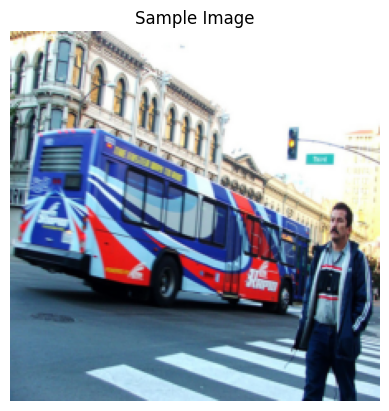

Câu hỏi: what does it say on back of bus
Giải thích: a red white and blue rapid bus crossing the intersection


In [8]:
def decode_tokens(tokens, vocab):
    words = [vocab.itos[t.item()] for t in tokens if vocab.itos[t.item()] not in ["<pad>", "<sos>", "<eos>"]]
    return " ".join(words)

sample_imgs, sample_qs, sample_exps = next(iter(train_loader))

print("--- KIỂM TRA KÍCH THƯỚC TENSOR ---")
print(f"Images: {sample_imgs.shape}")
print(f"Questions: {sample_qs.shape}")
print(f"Explanations: {sample_exps.shape}")
print("-" * 30)

sample_idx = 0
img_to_show = sample_imgs[sample_idx] / 2 + 0.5
img_to_show = img_to_show.numpy().transpose(1, 2, 0)

plt.imshow(img_to_show)
plt.axis('off')
plt.title("Sample Image")
plt.show()

print("Câu hỏi:", decode_tokens(sample_qs[sample_idx], vocab))
print("Giải thích:", decode_tokens(sample_exps[sample_idx], vocab))

**Bước 7: Xây dựng Kiến trúc Mô hình (From Scratch + Attention)**

Giải thích:

- Custom CNN: Lần này không dùng AdaptiveAvgPool ép về 1x1. Cấu trúc output là 49 vùng ảnh (lưới 7x7).

- Attention Layer: Tại mỗi bước sinh từ, mô hình tính toán trọng số (0->1) cho 49 vùng ảnh này dựa trên nội dung của LSTM Decoder để tạo ra Context Vector.

In [9]:
class CustomCNNAttention(nn.Module):
    def __init__(self):
        super(CustomCNNAttention, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(), nn.MaxPool2d(2) # Output: 256 channels, 7x7 grid
        )

    def forward(self, images):
        x = self.cnn(images)                # [B, 256, 7, 7]
        x = x.permute(0, 2, 3, 1)           # [B, 7, 7, 256]
        x = x.view(x.size(0), -1, x.size(-1)) # [B, 49 pixels, 256 dim]
        return x

class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        # encoder_out: [B, 49, 256], decoder_hidden: [B, dec_dim]
        att1 = self.encoder_att(encoder_out)                      # [B, 49, att_dim]
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)      # [B, 1, att_dim]
        att = self.full_att(torch.relu(att1 + att2)).squeeze(2)   # [B, 49]

        alpha = self.softmax(att)                                 # Trọng số attention cho 49 vùng
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)   # [B, 256]
        return context, alpha

class VQAE_Attention_Scratch(nn.Module):
    def __init__(self, vocab_size, img_dim=256, q_embed=256, q_hidden=256, dec_hidden=512, att_dim=256):
        super(VQAE_Attention_Scratch, self).__init__()
        self.vocab_size = vocab_size

        # 1. Encoders
        self.img_encoder = CustomCNNAttention()
        self.embedding = nn.Embedding(vocab_size, q_embed)
        self.q_lstm = nn.LSTM(q_embed, q_hidden, batch_first=True, bidirectional=True)

        # 2. Attention
        self.attention = Attention(img_dim, dec_hidden, att_dim)

        # 3. Fusion (Khởi tạo Decoder)
        self.init_h = nn.Linear(q_hidden * 2, dec_hidden)
        self.init_c = nn.Linear(q_hidden * 2, dec_hidden)

        # 4. Decoder (Nhận input = context_ảnh + embedding_từ_trước)
        self.dec_lstm = nn.LSTMCell(img_dim + q_embed, dec_hidden)
        self.fc_out = nn.Linear(dec_hidden, vocab_size)

    def forward(self, images, questions, explanations, teacher_forcing_ratio=0.5):
        batch_size = images.size(0)
        seq_len = explanations.size(1)

        img_features = self.img_encoder(images) # [B, 49, 256]

        q_embedded = self.embedding(questions)
        _, (q_h, q_c) = self.q_lstm(q_embedded)
        q_features = torch.cat((q_h[0], q_h[1]), dim=1) # [B, 512]

        # Khởi tạo state bằng câu hỏi
        h = self.init_h(q_features)
        c = self.init_c(q_features)

        outputs = torch.zeros(batch_size, seq_len, self.vocab_size).to(images.device)
        x = explanations[:, 0] # Bắt đầu bằng <sos>

        for t in range(1, seq_len):
            # Tính Attention context dựa trên hidden state hiện tại
            context, _ = self.attention(img_features, h) # context: [B, 256]

            embedded = self.embedding(x) # [B, 256]
            # Nối embedding từ hiện tại và context của ảnh
            lstm_input = torch.cat((embedded, context), dim=1)

            h, c = self.dec_lstm(lstm_input, (h, c))
            prediction = self.fc_out(h)

            outputs[:, t, :] = prediction

            if random.random() < teacher_forcing_ratio:
                x = explanations[:, t]
            else:
                x = prediction.argmax(1)

        return outputs

**Bước 8: Khai báo Hàm Huấn luyện và Đánh giá**

Giải thích:

- Các hàm lan truyền xuôi và tính ngược gradient. Tương tự như trước nhưng dành cho mạng mới.

In [10]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for imgs, questions, exps in dataloader:
        imgs, questions, exps = imgs.to(device), questions.to(device), exps.to(device)

        optimizer.zero_grad()
        outputs = model(imgs, questions, exps, teacher_forcing_ratio=0.5)

        outputs = outputs[:, 1:].reshape(-1, outputs.shape[-1])
        targets = exps[:, 1:].reshape(-1)

        loss = criterion(outputs, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)

def val_epoch(model, dataloader, criterion, device, pad_idx):
    model.eval()
    total_loss, correct, total_words = 0, 0, 0
    with torch.no_grad():
        for imgs, questions, exps in dataloader:
            imgs, questions, exps = imgs.to(device), questions.to(device), exps.to(device)
            outputs = model(imgs, questions, exps, teacher_forcing_ratio=0.0)

            outputs_flat = outputs[:, 1:].reshape(-1, outputs.shape[-1])
            targets_flat = exps[:, 1:].reshape(-1)

            loss = criterion(outputs_flat, targets_flat)
            total_loss += loss.item()

            predictions = outputs_flat.argmax(1)
            mask = (targets_flat != pad_idx)
            correct += (predictions[mask] == targets_flat[mask]).sum().item()
            total_words += mask.sum().item()

    return total_loss / len(dataloader), (correct / total_words) * 100

**Bước 9: Khởi tạo Mô hình và Thực thi Huấn luyện**

Giải thích:

- Chạy vòng lặp Epochs. Do mạng có Attention + tự build CNN, mô hình sẽ học nhanh hơn một chút so với bản không có Attention.

In [11]:
model = VQAE_Attention_Scratch(vocab_size=len(vocab)).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])

EPOCHS = 15
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("Bắt đầu huấn luyện mô hình (From Scratch + Có Attention)...")
for epoch in range(EPOCHS):
    t_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    v_loss, v_acc = val_epoch(model, val_loader, criterion, device, vocab.stoi["<pad>"])

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}%")

Bắt đầu huấn luyện mô hình (From Scratch + Có Attention)...
Epoch 1/15 | Train Loss: 5.3873 | Val Loss: 4.8902 | Val Acc: 19.12%
Epoch 2/15 | Train Loss: 4.7966 | Val Loss: 4.8283 | Val Acc: 19.19%
Epoch 3/15 | Train Loss: 4.6641 | Val Loss: 4.7972 | Val Acc: 19.27%
Epoch 4/15 | Train Loss: 4.5682 | Val Loss: 4.7901 | Val Acc: 19.34%
Epoch 5/15 | Train Loss: 4.4970 | Val Loss: 4.7907 | Val Acc: 19.21%
Epoch 6/15 | Train Loss: 4.4292 | Val Loss: 4.7786 | Val Acc: 19.10%
Epoch 7/15 | Train Loss: 4.3692 | Val Loss: 4.7708 | Val Acc: 19.13%
Epoch 8/15 | Train Loss: 4.3314 | Val Loss: 4.7463 | Val Acc: 19.20%
Epoch 9/15 | Train Loss: 4.2885 | Val Loss: 4.7352 | Val Acc: 18.97%
Epoch 10/15 | Train Loss: 4.2384 | Val Loss: 4.7259 | Val Acc: 19.13%
Epoch 11/15 | Train Loss: 4.1986 | Val Loss: 4.7209 | Val Acc: 18.97%
Epoch 12/15 | Train Loss: 4.1659 | Val Loss: 4.7061 | Val Acc: 18.88%
Epoch 13/15 | Train Loss: 4.1087 | Val Loss: 4.7132 | Val Acc: 18.92%
Epoch 14/15 | Train Loss: 4.0581 | Val 

**Bước 10: Trực quan hóa Lịch sử Huấn luyện (Learning Curves)**

Giải thích:

- Vẽ 2 biểu đồ quan trọng là sự giảm đi của Loss và sự gia tăng của Accuracy.

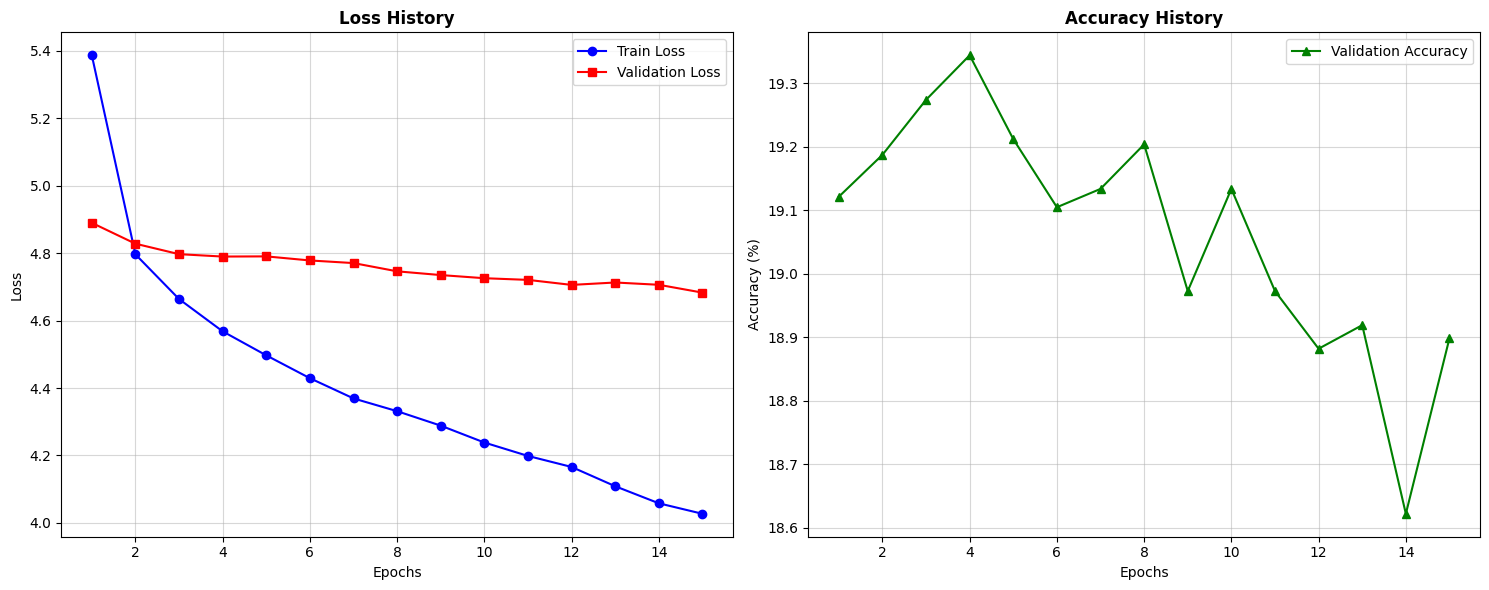

In [12]:
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', marker='s')
plt.title('Loss History', fontweight='bold')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.5)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['val_acc'], 'g-', label='Validation Accuracy', marker='^')
plt.title('Accuracy History', fontweight='bold')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)'); plt.legend(); plt.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

**Bước 11: Thử nghiệm thực tế (Inference)**

Giải thích:

- Nhập một ảnh và câu hỏi bất kỳ, mô hình sẽ chạy qua CNN, Question LSTM và dùng Attention Decoder sinh từng chữ để trả lời.

ĐANG DỰ ĐOÁN...


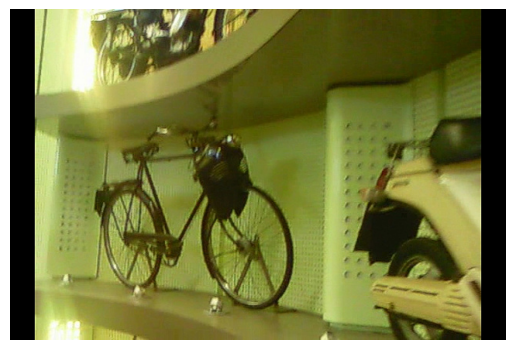

Câu hỏi: Is this a bicycle or a motorcycle?
Mô hình giải thích: a man is is a a a a
Ground Truth (Gốc): A bicycle is on the shelf in a display


In [13]:
def predict_vqa_attention(model, image_path, question, vocab, transform, device, max_len=20):
    model.eval()

    img = Image.open(image_path).convert("RGB")
    plt.imshow(img); plt.axis('off'); plt.show()

    img_tensor = transform(img).unsqueeze(0).to(device)
    q_tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(question) + [vocab.stoi["<eos>"]]
    q_tensor = torch.tensor(q_tokens).unsqueeze(0).to(device)

    with torch.no_grad():
        img_features = model.img_encoder(img_tensor) # [1, 49, 256]

        q_embedded = model.embedding(q_tensor)
        _, (q_h, q_c) = model.q_lstm(q_embedded)
        q_features = torch.cat((q_h[0], q_h[1]), dim=1)

        h = model.init_h(q_features)
        c = model.init_c(q_features)

        generated_words = []
        current_word = torch.tensor([vocab.stoi["<sos>"]]).to(device)

        for _ in range(max_len):
            context, _ = model.attention(img_features, h)
            embedded = model.embedding(current_word)

            lstm_input = torch.cat((embedded, context), dim=1)
            h, c = model.dec_lstm(lstm_input, (h, c))
            prediction = model.fc_out(h)

            pred_token = prediction.argmax(1).item()
            if pred_token == vocab.stoi["<eos>"]: break

            generated_words.append(vocab.itos[pred_token])
            current_word = torch.tensor([pred_token]).to(device)

    print(f"Câu hỏi: {question}")
    print(f"Mô hình giải thích: {' '.join(generated_words)}")

sample_test = val_data[10] # Chọn ngẫu nhiên 1 ảnh
print("ĐANG DỰ ĐOÁN...")
predict_vqa_attention(model, sample_test['image_path'], sample_test['question'], vocab, transform, device)
print(f"Ground Truth (Gốc): {sample_test['explanation']}")

In [14]:
# Cài đặt các thư viện hỗ trợ tính toán BLEU, ROUGE và CIDEr
!pip install nltk rouge-score pycocoevalcap

In [15]:
import torch
from tqdm import tqdm
from PIL import Image

# Import các hàm đánh giá từ pycocoevalcap (Đảm bảo đã chạy cell cài đặt pip trước đó)
from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

def evaluate_vqa_e_attention(model, data, vocab, transform, device, max_len=20, num_samples=None):
    model.eval() # Chuyển mô hình sang chế độ Evaluation

    gts = {} # Ground truths
    res = {} # Predictions

    # Nếu num_samples được chỉ định, đánh giá trên một tập con (vd 200 mẫu) để test code trước
    eval_data = data[:num_samples] if num_samples else data

    print(f"Đang tiến hành dự đoán trên {len(eval_data)} mẫu...")

    with torch.no_grad():
        for idx, sample in enumerate(tqdm(eval_data, desc="Predicting")):
            img_path = sample['image_path']
            question = sample['question']
            gt_explanation = sample['explanation'] # Câu giải thích gốc (Ground truth)

            # 1. Tiền xử lý ảnh
            img = Image.open(img_path).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)

            # 2. Tiền xử lý câu hỏi
            q_tokens = [vocab.stoi["<sos>"]] + vocab.numericalize(question) + [vocab.stoi["<eos>"]]
            q_tensor = torch.tensor(q_tokens).unsqueeze(0).to(device)

            # 3. Trích xuất đặc trưng (Encode)
            img_features = model.img_encoder(img_tensor) # Kích thước [1, 49, 256]

            q_embedded = model.embedding(q_tensor)
            _, (q_h, q_c) = model.q_lstm(q_embedded)
            q_features = torch.cat((q_h[0], q_h[1]), dim=1)

            # Khởi tạo trạng thái ẩn h, c cho Decoder
            h = model.init_h(q_features)
            c = model.init_c(q_features)

            # 4. Decode kết hợp Attention bằng Greedy Search
            generated_words = []
            current_word = torch.tensor([vocab.stoi["<sos>"]]).to(device)

            for _ in range(max_len):
                # Tính toán Attention context vector ở mỗi bước
                context, _ = model.attention(img_features, h)
                embedded = model.embedding(current_word)

                lstm_input = torch.cat((embedded, context), dim=1)
                h, c = model.dec_lstm(lstm_input, (h, c))
                prediction = model.fc_out(h)

                pred_token = prediction.argmax(1).item()
                if pred_token == vocab.stoi["<eos>"]:
                    break

                generated_words.append(vocab.itos[pred_token])

                # Từ dự đoán được trở thành input cho bước thời gian tiếp theo
                current_word = torch.tensor([pred_token]).to(device)

            pred_explanation = " ".join(generated_words)

            # Cần lưu vào dictionary với value là 1 mảng các câu string theo chuẩn của pycocoevalcap
            gts[str(idx)] = [gt_explanation]
            res[str(idx)] = [pred_explanation]

    # Khởi tạo các module tính toán metrics
    print("\nĐang tính toán các độ đo (Metrics)...")
    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr")
    ]

    results = {}
    for scorer, method in scorers:
        score, _ = scorer.compute_score(gts, res)
        if type(method) == list:
            for m, s in zip(method, score):
                results[m] = s
                print(f"{m}: {s:.4f}")
        else:
            results[method] = score
            print(f"{method}: {score:.4f}")

    return results

# =========================================================
# GỌI HÀM ĐÁNH GIÁ (Trên tập val_data)
# =========================================================
print("=== BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH VQA-E (CÓ ATTENTION) ===")

# Lưu ý: Hiện tại đang set num_samples=200 để chạy kiểm tra tốc độ/lỗi.
# Nếu bạn muốn đánh giá trên TOÀN BỘ TẬP VALIDATION, hãy đổi num_samples=None
metrics_results = evaluate_vqa_e_attention(
    model=model,
    data=val_data, # Sử dụng val_data hoặc test_data tương ứng
    vocab=vocab,
    transform=transform,
    device=device,
    num_samples=200
)

=== BẮT ĐẦU ĐÁNH GIÁ MÔ HÌNH VQA-E (CÓ ATTENTION) ===
Đang tiến hành dự đoán trên 200 mẫu...


Predicting: 100%|██████████| 200/200 [00:02<00:00, 71.04it/s]


Đang tính toán các độ đo (Metrics)...
{'testlen': 1661, 'reflen': 2225, 'guess': [1661, 1461, 1261, 1061], 'correct': [467, 84, 11, 1]}
ratio: 0.7465168539322488
BLEU-1: 0.2002
BLEU-2: 0.0905
BLEU-3: 0.0371
BLEU-4: 0.0136
ROUGE-L: 0.2137
CIDEr: 0.2310
